<a href="https://colab.research.google.com/github/aldrinjohny-ai/image-processing-lab/blob/main/image_processing_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving orange real.png to orange real (6).png
height: 452
width: 507
channels: 3


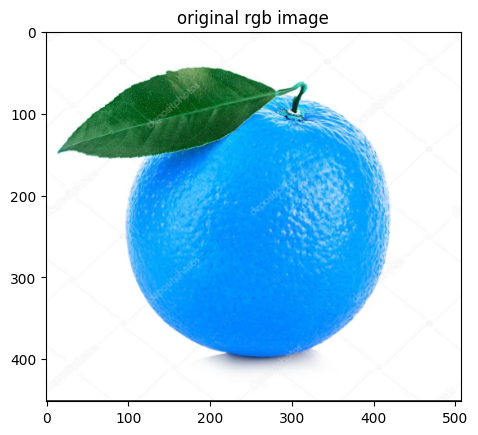

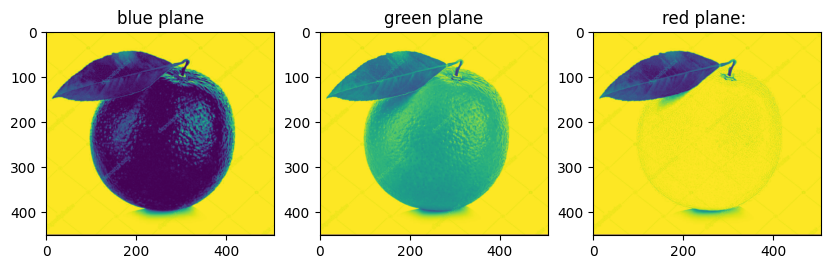

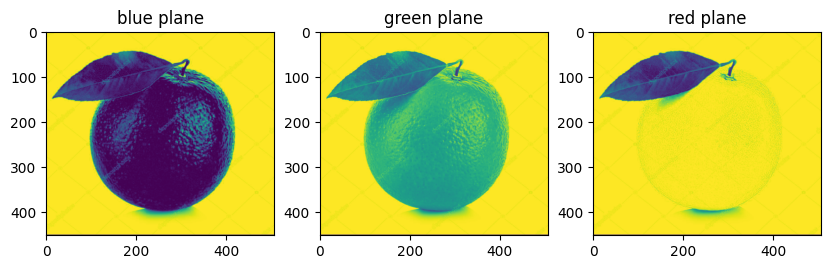

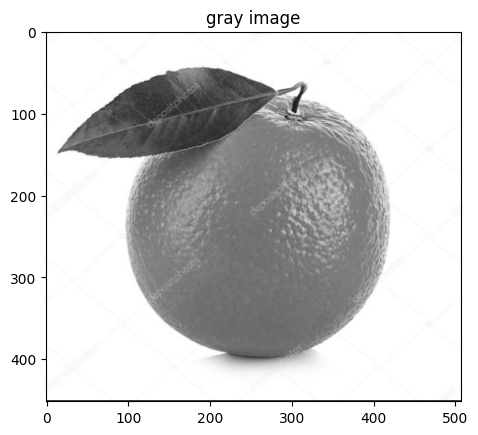

height 452
width 507


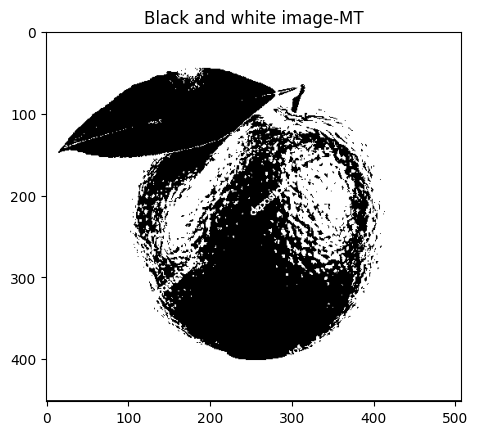

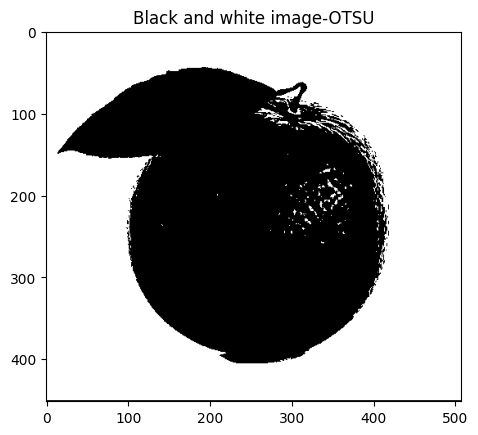

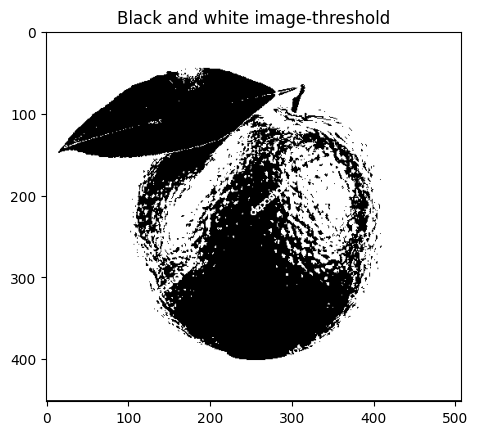

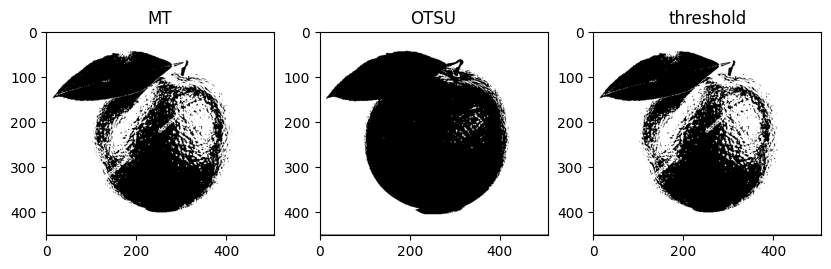

Sum of manual threshold image= 163476
Sum of the otsu image= 134540
Sum of the threshold image= 165439
height: 678
width: 760
height: 678
width: 760
height: 678
width: 760


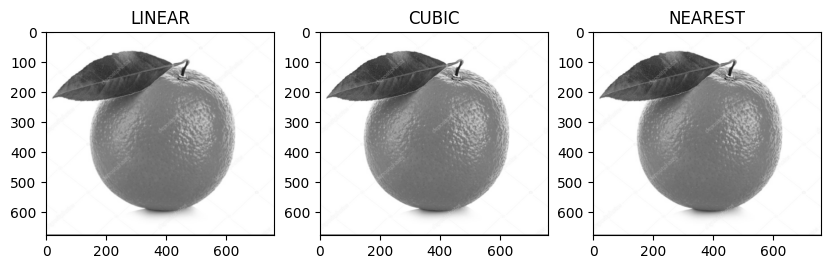

height: 452
width: 507
height: 452
width: 507


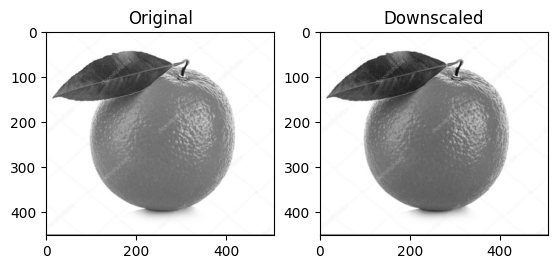

Mean square error: 2.890881639349985


In [ ]:
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
import cv2

upload=files.upload()
filename=next(iter(upload))

x1=cv2.imread(filename)
plt.imshow(x1)
plt.title("original rgb image")
h,w,c=x1.shape
print("height:",h)
print("width:",w)
print("channels:",c)
b_plane= x1[:,:,0]
g_plane= x1[:,:,1]
r_plane= x1[:,:,2]

plt.figure(figsize=(10,4))
plt.subplot(1,3,1);plt.imshow(b_plane);cmap="gray",plt.title("blue plane")
plt.subplot(1,3,2);plt.imshow(g_plane);cmap="gray",plt.title("green plane")
plt.subplot(1,3,3);plt.imshow(r_plane);cmap="gray",plt.title("red plane")


plt.imshow(b_plane)
plt.title("blue plane: ")
plt.imshow(g_plane)
plt.title("green plane: ")
plt.imshow(r_plane)
plt.title("red plane: ")
b,g,r=cv2.split(x1)
plt.figure(figsize=(10,4))
plt.subplot(1,3,1);plt.imshow(b);cmap="gray",plt.title("blue plane")
plt.subplot(1,3,2);plt.imshow(g);cmap="gray",plt.title("green plane")
plt.subplot(1,3,3);plt.imshow(r);cmap="gray",plt.title("red plane")
plt.show()

if c==3:
  x2=cv2.cvtColor(x1,cv2.COLOR_RGB2GRAY)
plt.imshow(x2,cmap='gray')
plt.title("gray image")
plt.show()
h,w=x2.shape
print("height",h)
print("width",w)

_, x4=cv2.threshold(x2,128,1,cv2.THRESH_BINARY)
plt.imshow(x4,cmap='gray')
plt.title("Black and white image-MT")
plt.show()

_,x5=cv2.threshold(x2,0,1,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
plt.imshow(x5,cmap='gray')
plt.title("Black and white image-OTSU")
plt.show()

x6=np.zeros_like(x2)
mn= np.min(x2)
mx=np.max(x2)
threshold=(mn+mx)/2
for i in range(x2.shape[0]):
  for j in range(x2.shape[1]):
    if x2[i,j]>threshold:
      x6[i,j]=1
    else:
      x6[i,j]=0

plt.imshow(x6,cmap='gray')
plt.title("Black and white image-threshold")
plt.show()

plt.figure(figsize=(10,4))
plt.subplot(1,3,1);plt.imshow(x4,cmap='gray');plt.title("MT")
plt.subplot(1,3,2);plt.imshow(x5,cmap='gray');plt.title("OTSU")
plt.subplot(1,3,3);plt.imshow(x6,cmap='gray');plt.title("threshold")
plt.show()

s1=np.sum(x4)
print("Sum of manual threshold image=",s1)
s2=np.sum(x5)
print("Sum of the otsu image=",s2)
s3=np.sum(x6)
print("Sum of the threshold image=",s3)

fx=1.5
fy=1.5

x7=cv2.resize(x2,None,fx=fx,fy=fy,interpolation=cv2.INTER_LINEAR)
x7h,x7w=x7.shape
print("height:",x7h)
print("width:",x7w)

x8=cv2.resize(x2,None,fx=fy,fy=fy,interpolation=cv2.INTER_CUBIC)
x8h,x8w=x8.shape
print("height:",x8h)
print("width:",x8w)

x9=cv2.resize(x2,None,fx=fx,fy=fy,interpolation=cv2.INTER_NEAREST)
x9h,x9w=x9.shape
print("height:",x9h)
print("width:",x9w)
plt.figure(figsize=(10,4))
plt.subplot(1,3,1);plt.imshow(x7,cmap='gray');plt.title("LINEAR")
plt.subplot(1,3,2);plt.imshow(x8,cmap='gray');plt.title("CUBIC")
plt.subplot(1,3,3);plt.imshow(x9,cmap='gray');plt.title("NEAREST")
plt.show()

fx=0.66667
fy=0.66667
x10=cv2.resize(x8,None,fx=fx,fy=fy,interpolation=cv2.INTER_AREA)
plt.figure(figsize=(10,4))
plt.subplot(1,3,1);plt.imshow(x2,cmap='gray');plt.title("Original")
plt.subplot(1,3,2);plt.imshow(x10,cmap='gray');plt.title("Downscaled")
print("height:",x2.shape[0])
print("width:",x2.shape[1])
print("height:",x10.shape[0])
print("width:",x10.shape[1])

plt.show()
diff=x2-x10
sq= diff*diff
mn= np.sum(sq)/(x2.shape[0]*x2.shape[1])
print("Mean square error:",mn)




Saving bfain tumor.jpg to bfain tumor (3).jpg
height: 423
width: 391
channel 3


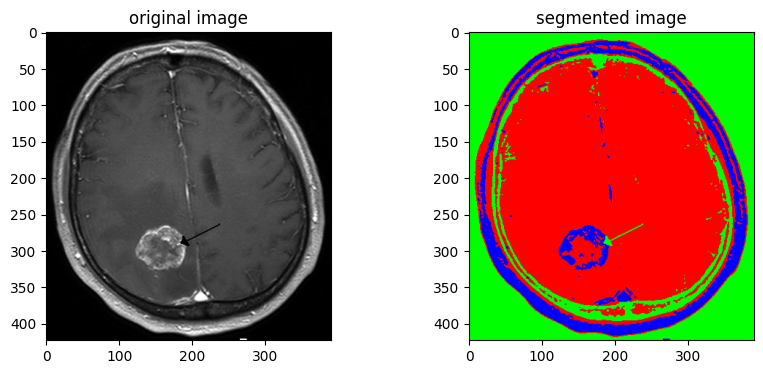

In [ ]:
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
import cv2
from sklearn.cluster import KMeans

upload=files.upload()
filename=next(iter(upload))
x1=cv2.imread(filename)
h,w,c=x1.shape
print("height:",h)
print("width:",w)
print("channel",c)

px=x1.reshape(-1,3)
k=3
kmeans=KMeans(n_clusters=k, n_init=10, random_state=42) # Added n_init and random_state for reproducibility
kmeans.fit(px)
labels=kmeans.labels_

# Define k colors for the clusters
cluster_colors=np.array([[255,0,0],[0,255,0],[0,0,255]],dtype=np.uint8)
sei=cluster_colors[labels].reshape(x1.shape)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1);plt.imshow(x1);plt.title("original image")
plt.subplot(1,2,2);plt.imshow(sei);plt.title("segmented image")
plt.show()